In [1]:
import os
os.environ["KMP_DUPLICATION_LIN_OK"] = "TRUE"

from dotenv import load_dotenv
load_dotenv()

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")



In [2]:
import glob
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_google_genai import GoogleGenerativeAIEmbeddings

DOCS_DIR = "sample_docs"
INDEX_DIR = "faiss_index"

def load_and_split(docs_dir):
    chunks=[]
    for path in glob.glob(os.path.join(docs_dir,"*.txt")):
        with open(path,"r",encoding="utf-8") as f:
            text=f.read()
        source=os.path.basename(path)
        paragraphs = [p.strip() for p in text.split("\n\n") if p.strip()]
        current=""
        for para in paragraphs:
            if len(current) + len(para) + 2 <=50:
                current=(current + "\n\n" +para).strip()
            else:
                if current:
                    chunks.append(Document(page_content=current,metadata={"source":source}))
                current=para
        if current:
             chunks.append(Document(page_content=current,metadata={"source":source}))
    return chunks

chunks=load_and_split(DOCS_DIR)
print(f"chunks: {len(chunks)}")
                


chunks: 5


In [3]:
embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-001")
vectorstore = FAISS.from_documents(chunks,embeddings)
vectorstore.save_local(INDEX_DIR)
print(f"Index saved to {INDEX_DIR}")

Index saved to faiss_index


In [16]:
from langchain_core.tools import tool

@tool
def add(a:int,b:int)->int:
    """Adds a to b"""
    return a+b

@tool
def multiply(a:int,b:int)->int:
    """Multiply a to b"""
    return a*b

@tool
def Divide(a:int,b:int)->int:
    """Divide a to b"""
    return a/b

@tool
def search_docs(query:str)->str:
    """Search the knowledge base for information about AML/ML concepts,
    LangGraph, RAG, embeddings, transaformers, and related topics"""
    embeddings= GoogleGenerativeAIEmbeddings(model="gemini-embedding-001")
    vectorstore=FAISS.load_local(INDEX_DIR,embeddings,allow_dangerous_deserialization=True)
    docs=vectorstore.as_retriever(search_kwargs={"k":3}).invoke(query)
    return "\n\n---\n\n".join(doc.page_content for doc in docs)



In [17]:
tools= [add, multiply, Divide, search_docs]
tools_by_name = {t.name:t for t in tools}



In [18]:
from langchain_groq import ChatGroq

model = ChatGroq(model="openai/gpt-oss-20b")
model_with_tools = model.bind_tools(tools)

model_with_tools

RunnableBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000022933896710>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000022933896C10>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'add', 'description': 'Adds a to b', 'parameters': {'properties': {'a': {'type': 'integer'}, 'b': {'type': 'integer'}}, 'required': ['a', 'b'], 'type': 'object'}}}, {'type': 'function', 'function': {'name': 'multiply', 'description': 'Multiply a to b', 'parameters': {'properties': {'a': {'type': 'integer'}, 'b': {'type': 'intege

In [19]:
from ast import operator
### state for langgraph
import operator
from typing import Annotated
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class MessageState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    llms_calls:int

In [20]:
from langchain_core.messages import SystemMessage,ToolMessage

def llm_call(state:MessageState)->dict:
    response = model_with_tools.invoke(
        [SystemMessage(content="""
        You're a helpful assistant that can perform arithmetic and answer questions about AI/ML concepts.
        Use search_docs for AI/ML questions, math tool for calculations.
        """)] + state["messages"]
    )

    return{
        "messages": [response],
        "llms_calls": state.get("llm_calls",0) + 1,
    }

def tool_node(state: MessageState) -> dict:
    results=[]
    for tool_call in state['messages'][-1].tool_calls:
        t=tools_by_name[tool_call['name']]
        observation = t.invoke(tool_call['args'])
        results.append(ToolMessage(content=str(observation),tool_call_id=tool_call['id']))
    return {"messages": results}


In [21]:
from typing import Literal
from langgraph.graph import END

def should_continue(state: MessageState)-> Literal["tool_node","__end__"]:
    last = state["messages"][-1]
    if hasattr(last,"tool_calls") and last.tool_calls:
        return "tool_node"
    return END

In [22]:
from langgraph.graph import StateGraph,START, END

agent_builder = StateGraph(MessageState)

agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

agent_builder.add_edge(START,"llm_call")
agent_builder.add_conditional_edges("llm_call",should_continue,["tool_node", END])
agent_builder.add_edge("tool_node","llm_call")

agent = agent_builder.compile()


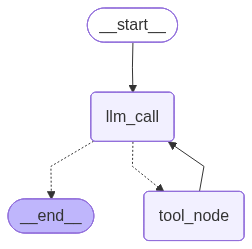

In [23]:
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))


In [24]:
from langchain_core.messages import AIMessage
from langchain_core.messages import HumanMessage

def run_agent(question:str):
    print(f"Q: {question}")
    result = agent.invoke({"messages": [HumanMessage(content=question)],"llm_call":0})
    for msg in result['messages']:
        if isinstance(msg,AIMessage) and msg.tool_calls:
            for tc in msg.tool_calls:
                print(f"tool:{tc['name']} args:{tc['args']}")
            if isinstance(msg, ToolMessage):
                print(f"result:{msg.content[:120]}")
    print(f"A: {result['messages'][-1].content}")
    print()

In [25]:
run_agent("What is 12 times 8 ?")

Q: What is 12 times 8 ?
tool:multiply args:{'a': 12, 'b': 8}
A: 12 times 8 equals 96.



In [26]:
run_agent("What is langGraph?")

Q: What is langGraph?
tool:search_docs args:{'query': 'langGraph'}
A: **LangGraph** is a framework created by the LangChain team (now part of the broader LangChain ecosystem) that lets developers build *graph‑structured* conversational AI applications. Think of it as a way to design and execute complex, multi‑step dialogue flows where each node can be a language‑model call, a tool invocation, a memory read/write, or any other custom logic.

---

### Core ideas

| Feature | What it does | Why it matters |
|---------|--------------|----------------|
| **Graph‑based flow** | You model a conversation as a directed graph of nodes and edges. | Makes it easy to visualize, debug, and modify the dialogue flow, especially for non‑linear or branching interactions. |
| **LLM nodes** | Nodes that call a large language model (OpenAI, Anthropic, etc.). | Keeps the LLM invocation logic separate from business logic. |
| **Tool nodes** | Nodes that run external APIs, databases, or custom code. | Lets yo